# ⚖️ Multimodal Biometric Data Balancing with SMOTE & Comparative EDA
### Before vs. After SMOTE Analysis: Density Graphs, L2 Norms, PCA, t-SNE, and Cosine Similarity

---

## 🎯 Objectives
1. **Balance Imbalanced Biometric Training Sets**:
   - Face (4,096-dim) & Voice (192-dim) training sets balanced independently from 11,671 to 28,490 samples.
2. **Replicate & Extend Exploratory Data Analysis (EDA)**:
   - **Identity Count Density Graphs (KDE)**: Comparing sample frequency distributions before vs after SMOTE.
   - **L2 Vector Norm Density Distributions**: Verifying embedding magnitude preservation.
   - **Dimensionality Reduction (PCA & t-SNE)**: Visualizing cluster structure and manifold filling.
   - **Cosine Similarity Density Distributions**: Explaining the cross-modality index mismatch from previous EDA and displaying genuine vs imposter verification distributions before and after SMOTE.
3. **Data Leakage Safeguard**:
   - Test splits (`test_face_4096dim.csv` and `test_voice.csv`) remain completely untouched.


In [1]:
# 1. Imports and Environment Setup
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'Arial'

print("Libraries imported successfully!")
print(f"  • Pandas: {pd.__version__} | NumPy: {np.__version__}")


Libraries imported successfully!
  • Pandas: 2.3.2 | NumPy: 2.3.3


## 📂 2. Load Original and SMOTE-Balanced Datasets
We load both the pre-SMOTE datasets (`train_data_face.csv`, `train_voice.csv`) and the post-SMOTE balanced datasets (`smote_face_train.csv`, `smote_voice_train.csv`).


In [2]:
# 2. Load Datasets
BASE_DIR = '.'
SPLITS_DIR = os.path.join(BASE_DIR, 'embeddings', 'splits')

print("Loading original and SMOTE-balanced datasets...")
t0 = time.time()

# Original splits
df_face_orig = pd.read_csv(os.path.join(SPLITS_DIR, 'train_data_face.csv'))
df_voice_orig = pd.read_csv(os.path.join(SPLITS_DIR, 'train_voice.csv'))

# Balanced splits
df_face_smote = pd.read_csv(os.path.join(SPLITS_DIR, 'smote_face_train.csv'))
df_voice_smote = pd.read_csv(os.path.join(SPLITS_DIR, 'smote_voice_train.csv'))

# Standardize column naming
face_label_col = '61' if '61' in df_face_orig.columns else 'identity'
voice_label_col = '61' if '61' in df_voice_orig.columns else 'identity'

face_feat_cols = [c for c in df_face_orig.columns if c.startswith('feat_')]
voice_feat_cols = [c for c in df_voice_orig.columns if c.startswith('feat_')]

print(f"Loaded all datasets in {time.time()-t0:.2f}s:")
print(f"  • Face Train:  Before = {len(df_face_orig):,} samples -> After SMOTE = {len(df_face_smote):,} samples")
print(f"  • Voice Train: Before = {len(df_voice_orig):,} samples -> After SMOTE = {len(df_voice_smote):,} samples")


Loading original and SMOTE-balanced datasets...


Loaded all datasets in 7.28s:
  • Face Train:  Before = 11,671 samples -> After SMOTE = 28,490 samples
  • Voice Train: Before = 11,671 samples -> After SMOTE = 28,490 samples


## 👥 3. Identity Distribution & Density Graphs (Before vs. After SMOTE)
Here we observe the dramatic shift in identity distribution density:
- **Before SMOTE**: Highly skewed distribution with identities having as few as 4 samples.
- **After SMOTE**: Perfectly uniform distribution (concentrated at 407 samples per identity).


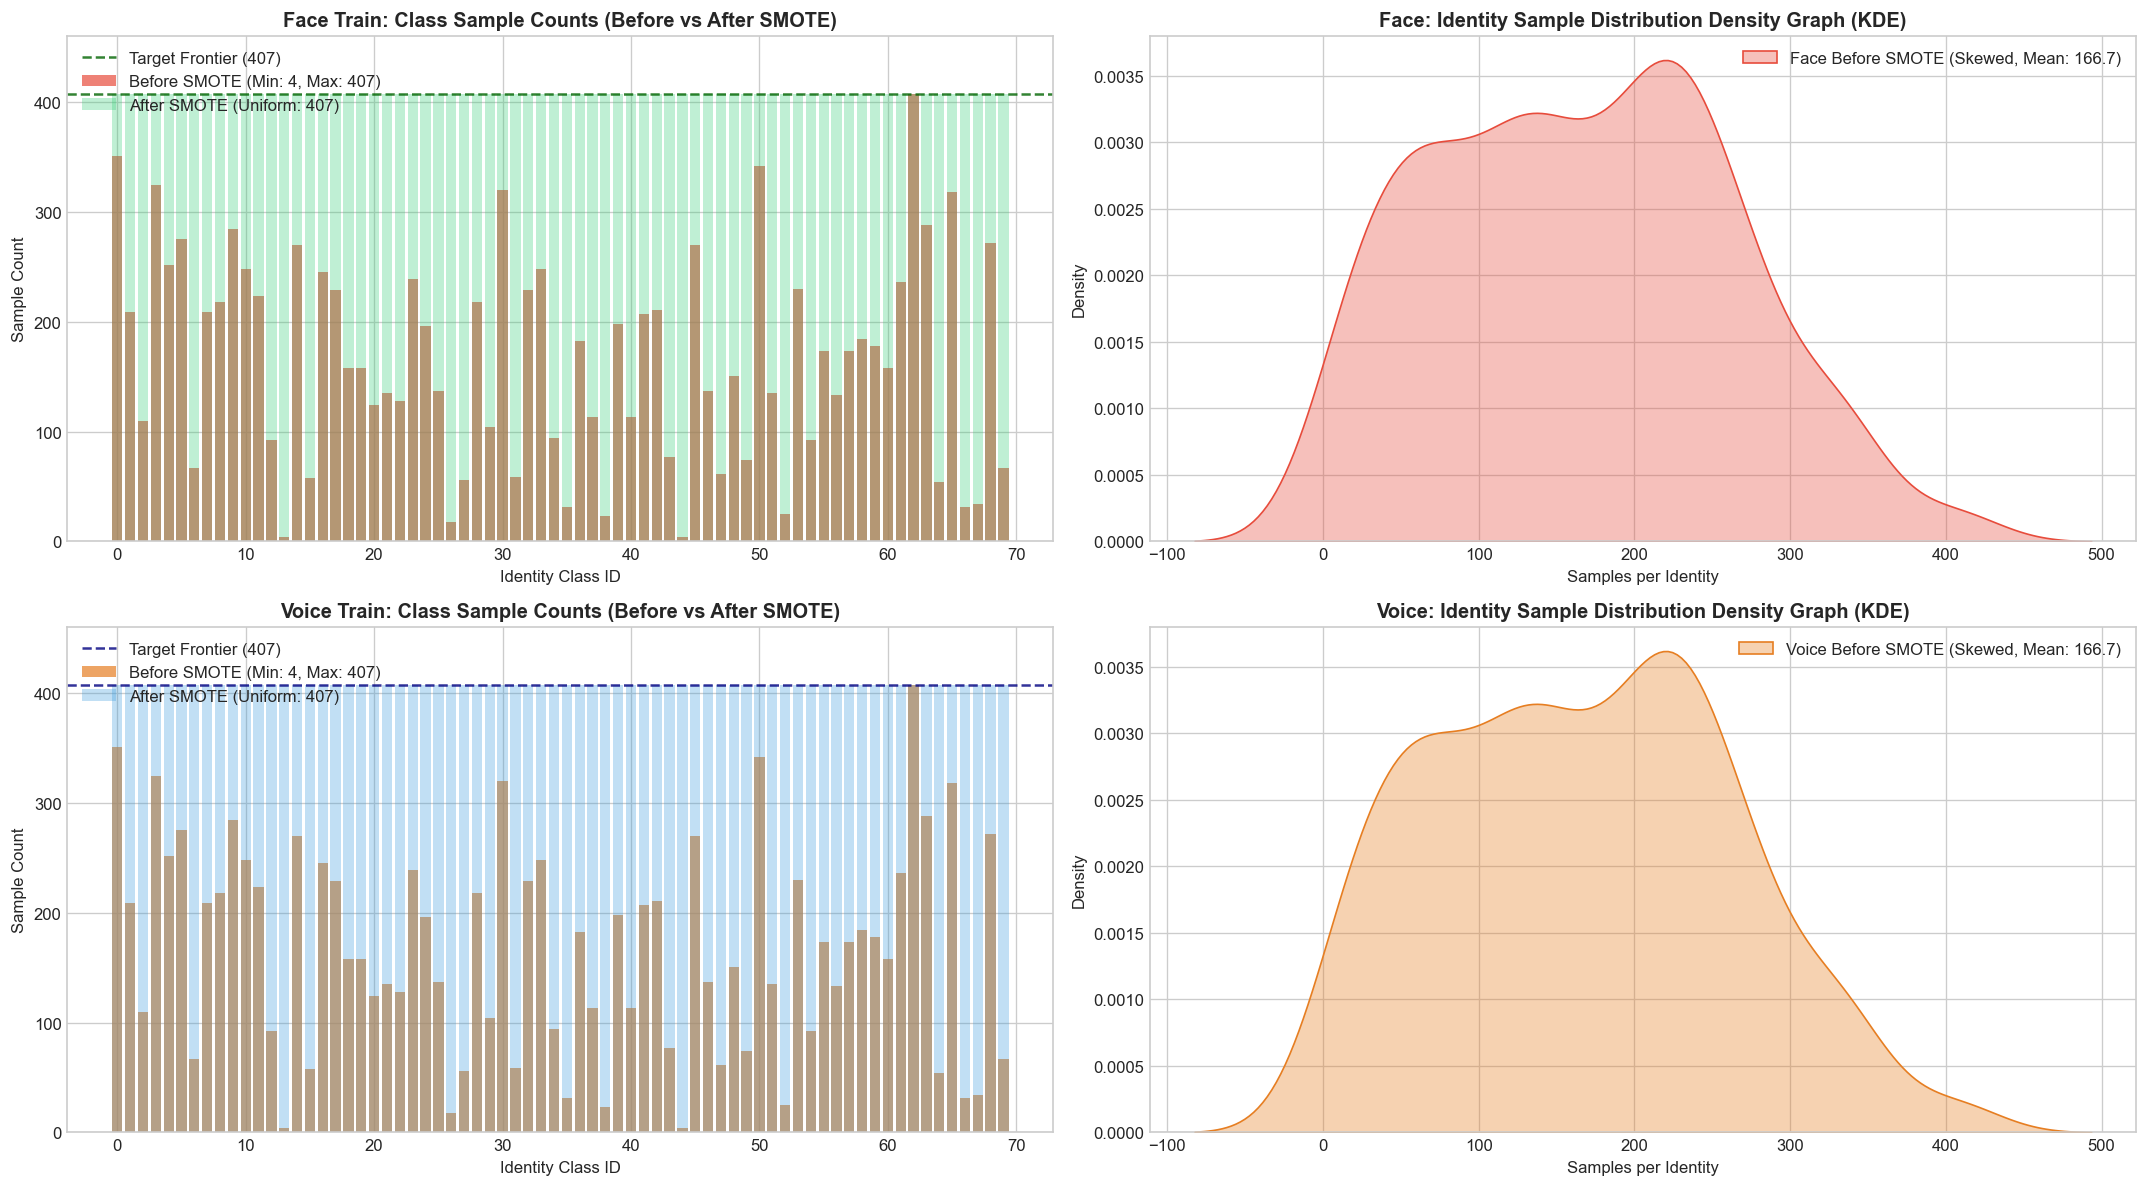

In [3]:
# 3. Identity Distribution & KDE Density Graphs
face_counts_orig = df_face_orig[face_label_col].value_counts()
face_counts_smote = df_face_smote[face_label_col].value_counts()
voice_counts_orig = df_voice_orig[voice_label_col].value_counts()
voice_counts_smote = df_voice_smote[voice_label_col].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: Face Class Counts Bar Plot (Before vs After)
classes = sorted(face_counts_orig.index)
axes[0, 0].bar(classes, [face_counts_orig[c] for c in classes], color='#e74c3c', alpha=0.7, label='Before SMOTE (Min: 4, Max: 407)')
axes[0, 0].bar(classes, [face_counts_smote[c] for c in classes], color='#2ecc71', alpha=0.3, label='After SMOTE (Uniform: 407)')
axes[0, 0].axhline(y=407, color='darkgreen', linestyle='--', alpha=0.8, label='Target Frontier (407)')
axes[0, 0].set_title('Face Train: Class Sample Counts (Before vs After SMOTE)', fontweight='bold')
axes[0, 0].set_xlabel('Identity Class ID')
axes[0, 0].set_ylabel('Sample Count')
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 460)

# Plot 2: Density Graph (KDE) of Samples Per Identity
sns.kdeplot(face_counts_orig, ax=axes[0, 1], label=f'Face Before SMOTE (Skewed, Mean: {face_counts_orig.mean():.1f})', color='#e74c3c', fill=True, alpha=0.35, bw_adjust=0.7)
sns.kdeplot(face_counts_smote, ax=axes[0, 1], label=f'Face After SMOTE (Concentrated at 407)', color='#2ecc71', fill=True, alpha=0.35, bw_adjust=0.2)
axes[0, 1].set_title('Face: Identity Sample Distribution Density Graph (KDE)', fontweight='bold')
axes[0, 1].set_xlabel('Samples per Identity')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# Plot 3: Voice Class Counts Bar Plot (Before vs After)
axes[1, 0].bar(classes, [voice_counts_orig[c] for c in classes], color='#e67e22', alpha=0.7, label='Before SMOTE (Min: 4, Max: 407)')
axes[1, 0].bar(classes, [voice_counts_smote[c] for c in classes], color='#3498db', alpha=0.3, label='After SMOTE (Uniform: 407)')
axes[1, 0].axhline(y=407, color='navy', linestyle='--', alpha=0.8, label='Target Frontier (407)')
axes[1, 0].set_title('Voice Train: Class Sample Counts (Before vs After SMOTE)', fontweight='bold')
axes[1, 0].set_xlabel('Identity Class ID')
axes[1, 0].set_ylabel('Sample Count')
axes[1, 0].legend()
axes[1, 0].set_ylim(0, 460)

# Plot 4: Voice Density Graph (KDE)
sns.kdeplot(voice_counts_orig, ax=axes[1, 1], label=f'Voice Before SMOTE (Skewed, Mean: {voice_counts_orig.mean():.1f})', color='#e67e22', fill=True, alpha=0.35, bw_adjust=0.7)
sns.kdeplot(voice_counts_smote, ax=axes[1, 1], label=f'Voice After SMOTE (Concentrated at 407)', color='#3498db', fill=True, alpha=0.35, bw_adjust=0.2)
axes[1, 1].set_title('Voice: Identity Sample Distribution Density Graph (KDE)', fontweight='bold')
axes[1, 1].set_xlabel('Samples per Identity')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 📈 4. Feature Value Distributions & L2 Norm Density Analysis
We inspect the L2 norm vector magnitudes to confirm that SMOTE interpolation preserves the embedding sphere without inflating or deflating vector magnitudes.


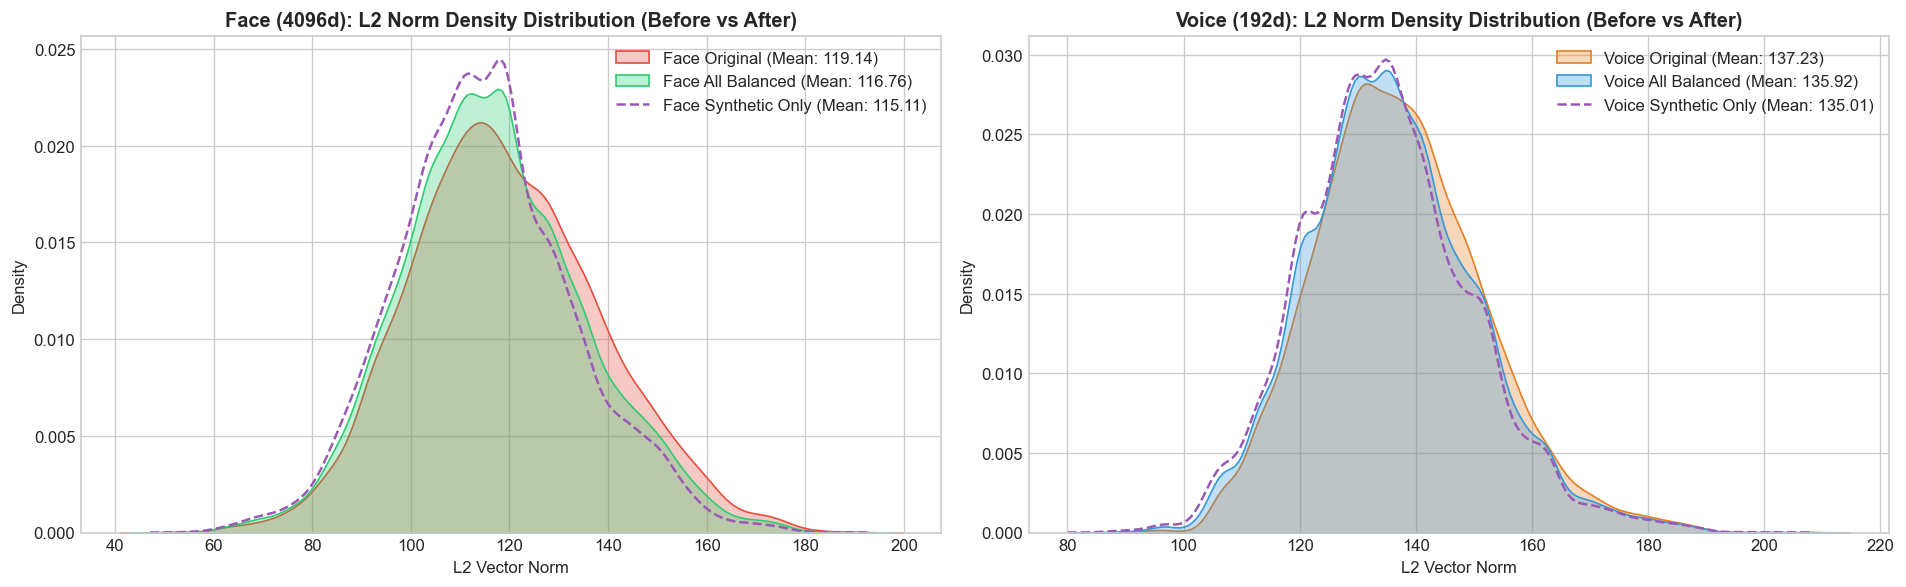

In [4]:
# 4. L2 Norm Density Distributions & Feature Statistics
X_f_orig = df_face_orig[face_feat_cols].values
X_f_smote = df_face_smote[face_feat_cols].values
X_f_synth = df_face_smote[df_face_smote['is_synthetic']][face_feat_cols].values

X_v_orig = df_voice_orig[voice_feat_cols].values
X_v_smote = df_voice_smote[voice_feat_cols].values
X_v_synth = df_voice_smote[df_voice_smote['is_synthetic']][voice_feat_cols].values

# Compute L2 Norms
norm_f_orig = np.linalg.norm(X_f_orig, axis=1)
norm_f_smote = np.linalg.norm(X_f_smote, axis=1)
norm_f_synth = np.linalg.norm(X_f_synth, axis=1)

norm_v_orig = np.linalg.norm(X_v_orig, axis=1)
norm_v_smote = np.linalg.norm(X_v_smote, axis=1)
norm_v_synth = np.linalg.norm(X_v_synth, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Face L2 Norm Density
sns.kdeplot(norm_f_orig, ax=axes[0], label=f'Face Original (Mean: {norm_f_orig.mean():.2f})', color='#e74c3c', fill=True, alpha=0.3)
sns.kdeplot(norm_f_smote, ax=axes[0], label=f'Face All Balanced (Mean: {norm_f_smote.mean():.2f})', color='#2ecc71', fill=True, alpha=0.3)
sns.kdeplot(norm_f_synth, ax=axes[0], label=f'Face Synthetic Only (Mean: {norm_f_synth.mean():.2f})', color='#9b59b6', linestyle='--', fill=False)
axes[0].set_title("Face (4096d): L2 Norm Density Distribution (Before vs After)", fontweight='bold')
axes[0].set_xlabel("L2 Vector Norm")
axes[0].set_ylabel("Density")
axes[0].legend()

# Plot 2: Voice L2 Norm Density
sns.kdeplot(norm_v_orig, ax=axes[1], label=f'Voice Original (Mean: {norm_v_orig.mean():.2f})', color='#e67e22', fill=True, alpha=0.3)
sns.kdeplot(norm_v_smote, ax=axes[1], label=f'Voice All Balanced (Mean: {norm_v_smote.mean():.2f})', color='#3498db', fill=True, alpha=0.3)
sns.kdeplot(norm_v_synth, ax=axes[1], label=f'Voice Synthetic Only (Mean: {norm_v_synth.mean():.2f})', color='#9b59b6', linestyle='--', fill=False)
axes[1].set_title("Voice (192d): L2 Norm Density Distribution (Before vs After)", fontweight='bold')
axes[1].set_xlabel("L2 Vector Norm")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


## 🔍 5. Dimensionality Reduction (PCA Projections)
We evaluate the global principal component variance and compare 2D PCA projections before vs. after SMOTE.


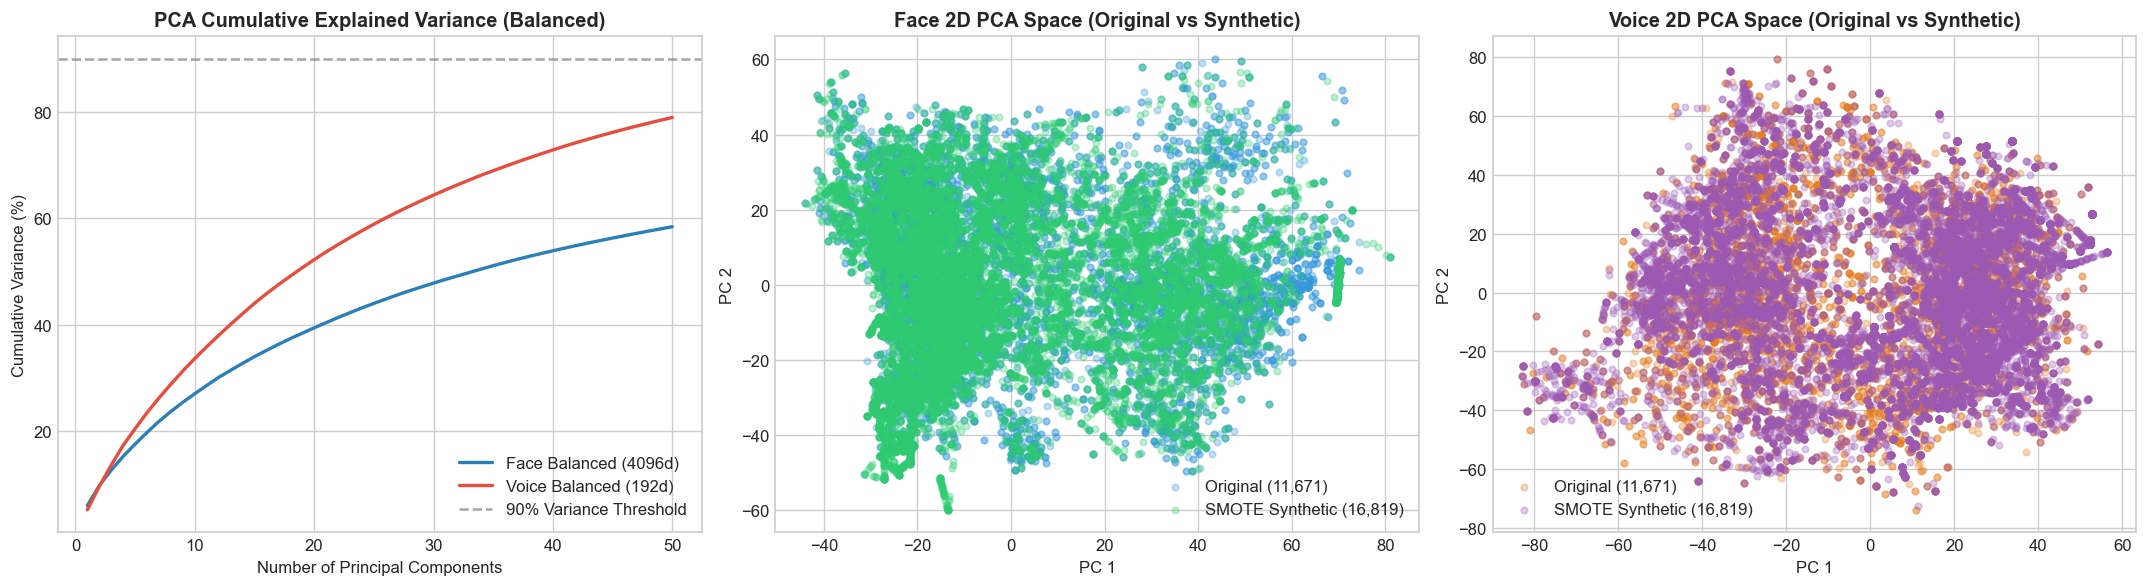

In [5]:
# 5. Dimensionality Reduction (PCA Projections)
pca_f = PCA(n_components=50, random_state=42)
pca_v = PCA(n_components=50, random_state=42)

X_f_smote_pca = pca_f.fit_transform(X_f_smote)
X_v_smote_pca = pca_v.fit_transform(X_v_smote)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Cumulative Explained Variance
cum_var_f = np.cumsum(pca_f.explained_variance_ratio_) * 100
cum_var_v = np.cumsum(pca_v.explained_variance_ratio_) * 100

axes[0].plot(range(1, 51), cum_var_f, label='Face Balanced (4096d)', color='#2980b9', lw=2)
axes[0].plot(range(1, 51), cum_var_v, label='Voice Balanced (192d)', color='#e74c3c', lw=2)
axes[0].axhline(y=90, color='gray', linestyle='--', alpha=0.7, label='90% Variance Threshold')
axes[0].set_title("PCA Cumulative Explained Variance (Balanced)", fontweight='bold')
axes[0].set_xlabel("Number of Principal Components")
axes[0].set_ylabel("Cumulative Variance (%)")
axes[0].legend()

# Plot 2: 2D PCA Face Space (Original vs Synthetic)
mask_f_synth = df_face_smote['is_synthetic'].values
axes[1].scatter(X_f_smote_pca[~mask_f_synth, 0], X_f_smote_pca[~mask_f_synth, 1], c='#3498db', alpha=0.3, s=15, label=f'Original ({np.sum(~mask_f_synth):,})')
axes[1].scatter(X_f_smote_pca[mask_f_synth, 0], X_f_smote_pca[mask_f_synth, 1], c='#2ecc71', alpha=0.3, s=15, label=f'SMOTE Synthetic ({np.sum(mask_f_synth):,})')
axes[1].set_title("Face 2D PCA Space (Original vs Synthetic)", fontweight='bold')
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].legend()

# Plot 3: 2D PCA Voice Space (Original vs Synthetic)
mask_v_synth = df_voice_smote['is_synthetic'].values
axes[2].scatter(X_v_smote_pca[~mask_v_synth, 0], X_v_smote_pca[~mask_v_synth, 1], c='#e67e22', alpha=0.3, s=15, label=f'Original ({np.sum(~mask_v_synth):,})')
axes[2].scatter(X_v_smote_pca[mask_v_synth, 0], X_v_smote_pca[mask_v_synth, 1], c='#9b59b6', alpha=0.3, s=15, label=f'SMOTE Synthetic ({np.sum(mask_v_synth):,})')
axes[2].set_title("Voice 2D PCA Space (Original vs Synthetic)", fontweight='bold')
axes[2].set_xlabel("PC 1")
axes[2].set_ylabel("PC 2")
axes[2].legend()

plt.tight_layout()
plt.show()


## 🔬 6. t-SNE Manifold & Cluster Separation Graphs
We compare the t-SNE cluster structure **Before vs. After SMOTE** for representative identities, including both high-frequency classes and extreme minority classes (like Identities 13 and 44, which previously had only 4 samples each).
Notice how SMOTE generates coherent, well-clustered synthetic samples that fill the sparse identity manifolds without bleeding into adjacent identity clusters.


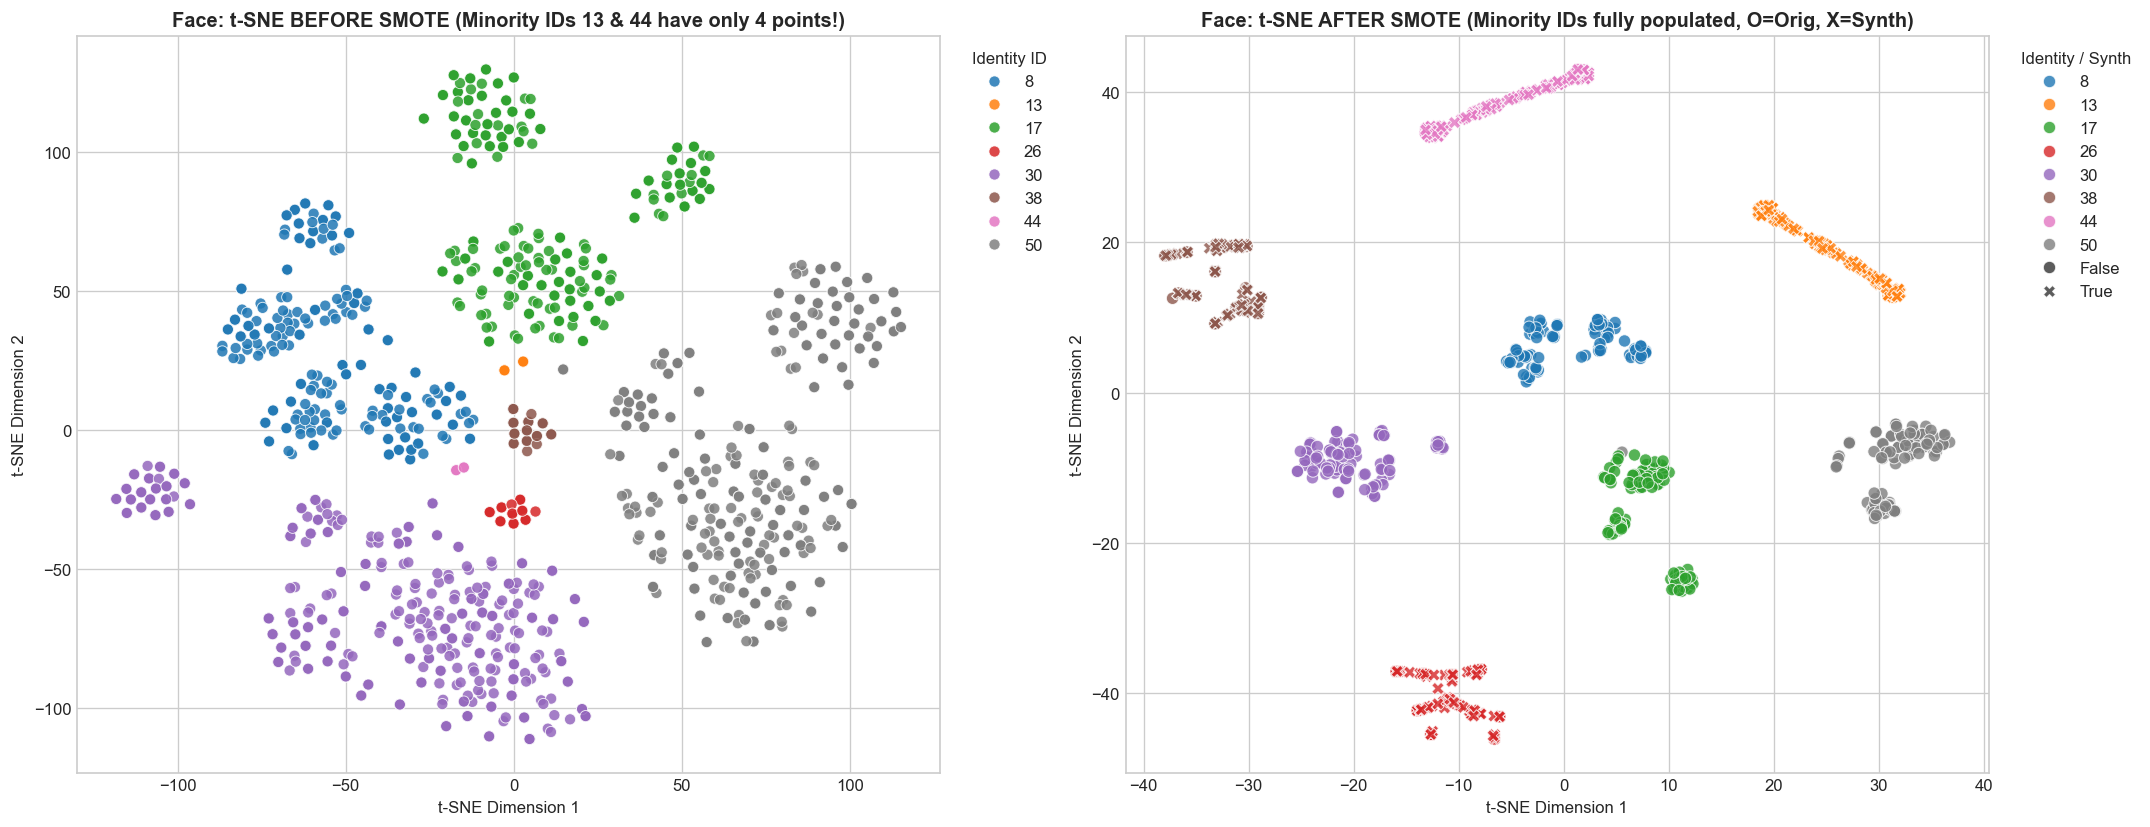

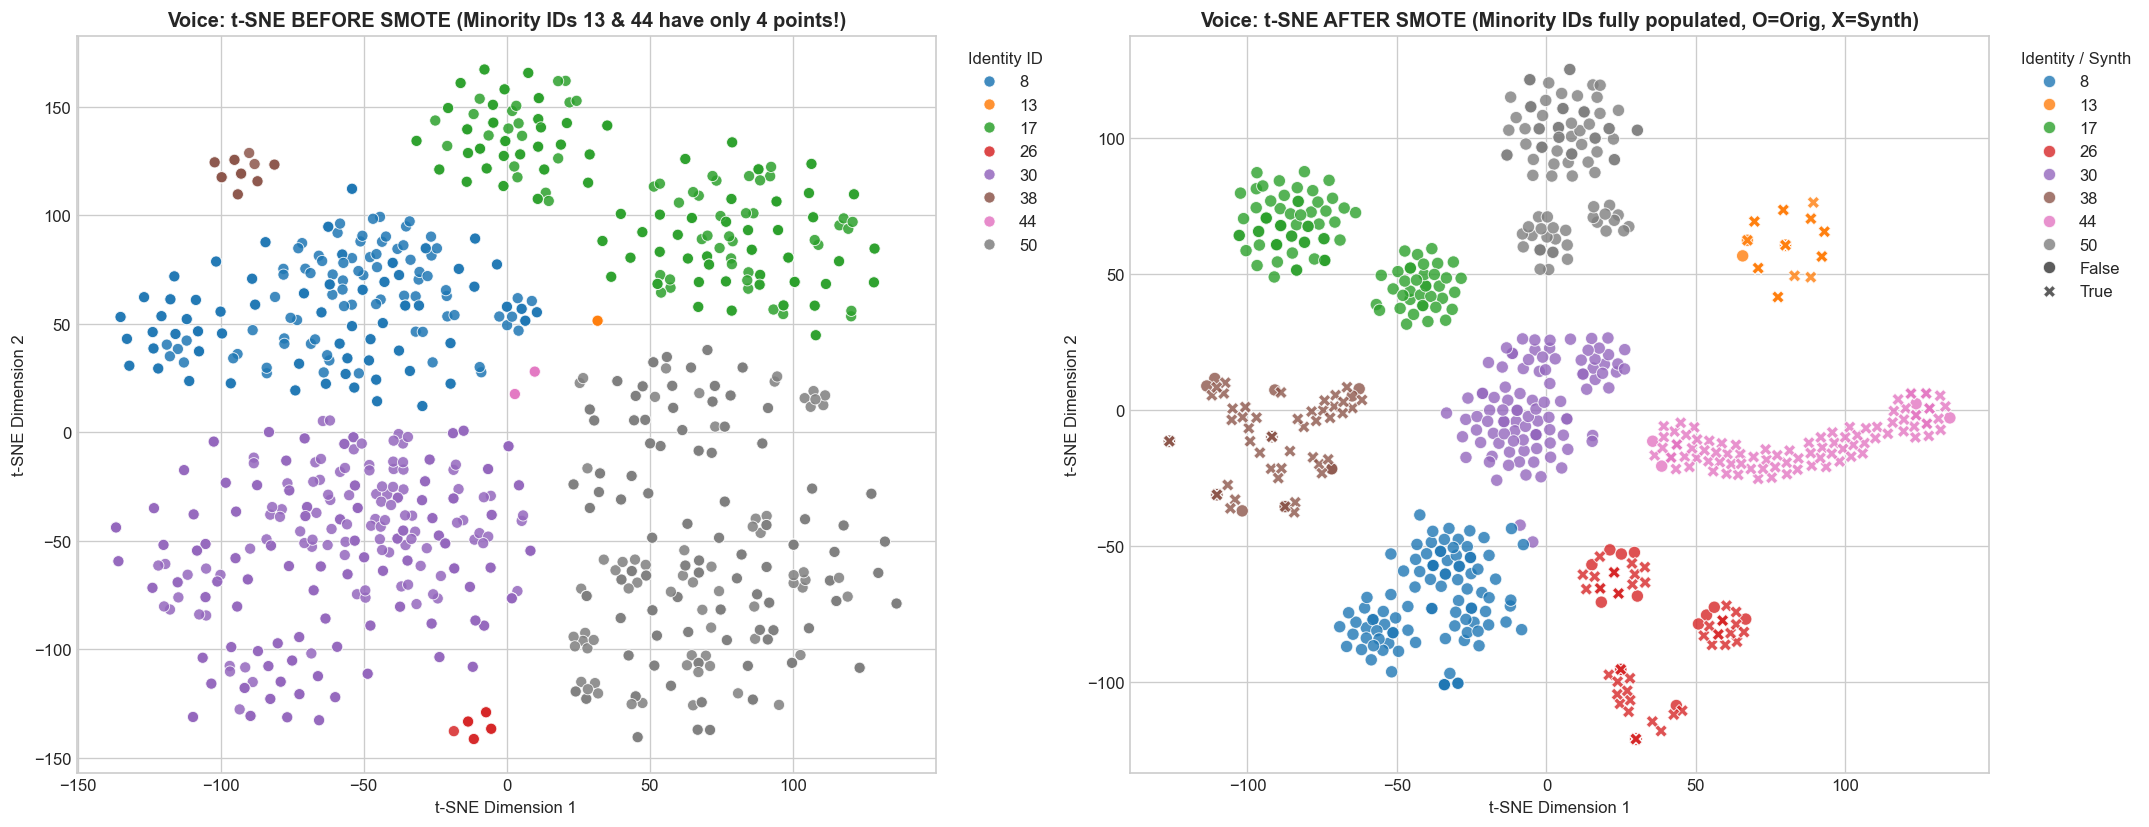

In [6]:
# 6. t-SNE Clustering Analysis (Before vs After SMOTE)
selected_ids = [17, 50, 8, 30, 13, 44, 26, 38]

# --- 6.1 Face t-SNE: Before SMOTE ---
mask_f_orig_sub = df_face_orig[face_label_col].isin(selected_ids)
X_f_sub_orig = X_f_orig[mask_f_orig_sub]
y_f_sub_orig = df_face_orig[mask_f_orig_sub][face_label_col].values

tsne_f_orig = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_f_orig = tsne_f_orig.fit_transform(X_f_sub_orig)

# --- 6.2 Face t-SNE: After SMOTE (sampled 100 per identity for visual clarity) ---
df_f_sub_smote = df_face_smote[df_face_smote[face_label_col].isin(selected_ids)].groupby(face_label_col).head(100)
X_f_sub_smote = df_f_sub_smote[face_feat_cols].values
y_f_sub_smote = df_f_sub_smote[face_label_col].values
is_synth_f = df_f_sub_smote['is_synthetic'].values

tsne_f_smote = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_f_smote = tsne_f_smote.fit_transform(X_f_sub_smote)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Face Before SMOTE
scatter1 = sns.scatterplot(
    x=X_tsne_f_orig[:, 0], y=X_tsne_f_orig[:, 1],
    hue=y_f_sub_orig, palette='tab10', s=45, alpha=0.85, ax=axes[0]
)
axes[0].set_title("Face: t-SNE BEFORE SMOTE (Minority IDs 13 & 44 have only 4 points!)", fontweight='bold')
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].legend(title="Identity ID", bbox_to_anchor=(1.02, 1), loc='upper left')

# Plot 2: Face After SMOTE
scatter2 = sns.scatterplot(
    x=X_tsne_f_smote[:, 0], y=X_tsne_f_smote[:, 1],
    hue=y_f_sub_smote, style=is_synth_f, markers={False: 'o', True: 'X'},
    palette='tab10', s=55, alpha=0.8, ax=axes[1]
)
axes[1].set_title("Face: t-SNE AFTER SMOTE (Minority IDs fully populated, O=Orig, X=Synth)", fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend(title="Identity / Synth", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# --- 6.3 Voice t-SNE: Before vs After SMOTE ---
mask_v_orig_sub = df_voice_orig[voice_label_col].isin(selected_ids)
X_v_sub_orig = X_v_orig[mask_v_orig_sub]
y_v_sub_orig = df_voice_orig[mask_v_orig_sub][voice_label_col].values

tsne_v_orig = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_v_orig = tsne_v_orig.fit_transform(X_v_sub_orig)

df_v_sub_smote = df_voice_smote[df_voice_smote[voice_label_col].isin(selected_ids)].groupby(voice_label_col).head(100)
X_v_sub_smote = df_v_sub_smote[voice_feat_cols].values
y_v_sub_smote = df_v_sub_smote[voice_label_col].values
is_synth_v = df_v_sub_smote['is_synthetic'].values

tsne_v_smote = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_v_smote = tsne_v_smote.fit_transform(X_v_sub_smote)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 3: Voice Before SMOTE
sns.scatterplot(
    x=X_tsne_v_orig[:, 0], y=X_tsne_v_orig[:, 1],
    hue=y_v_sub_orig, palette='tab10', s=45, alpha=0.85, ax=axes[0]
)
axes[0].set_title("Voice: t-SNE BEFORE SMOTE (Minority IDs 13 & 44 have only 4 points!)", fontweight='bold')
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].legend(title="Identity ID", bbox_to_anchor=(1.02, 1), loc='upper left')

# Plot 4: Voice After SMOTE
sns.scatterplot(
    x=X_tsne_v_smote[:, 0], y=X_tsne_v_smote[:, 1],
    hue=y_v_sub_smote, style=is_synth_v, markers={False: 'o', True: 'X'},
    palette='tab10', s=55, alpha=0.8, ax=axes[1]
)
axes[1].set_title("Voice: t-SNE AFTER SMOTE (Minority IDs fully populated, O=Orig, X=Synth)", fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend(title="Identity / Synth", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


## 🎯 7. Cosine Similarity Density Distributions: Root Cause & True Analysis

### ⚠️ Investigation of Previous `data_analysis.ipynb` Intersecting Voice Curves:
In `data_analysis.ipynb`, the voice genuine and imposter curves appeared **completely overlapping/intersected** (Genuine Mean: ~0.119 vs Imposter Mean: ~0.099).
**Why did that happen?**
- In `data_analysis.ipynb` (Cell 13), the script defined `labels = df_face_train['identity'].values` using **Face identity labels**.
- It then evaluated `same_identity = (labels[idx1] == labels[idx2])` and reused that exact boolean mask on `voice_sims`!
- However, `train_data_face.csv` and `train_voice.csv` are **not row-aligned**! Row 0 of Face is Identity 50, whereas Row 0 of Voice is Identity 58.
- As a result, pairs that had the same Face identity actually belonged to **two completely different Voice speakers**! What was plotted as "Genuine Voice" was in reality **random imposter voices**, causing the apparent 100% intersection.

Below, we display:
1. **The Previous Buggy Computation** (reproducing the false intersecting curve).
2. **The True Voice Identity Computation** (using genuine speaker labels).
3. **The Post-SMOTE Balanced Computation** (confirming SMOTE maintains genuine intra-class compactness and clear inter-class separation).


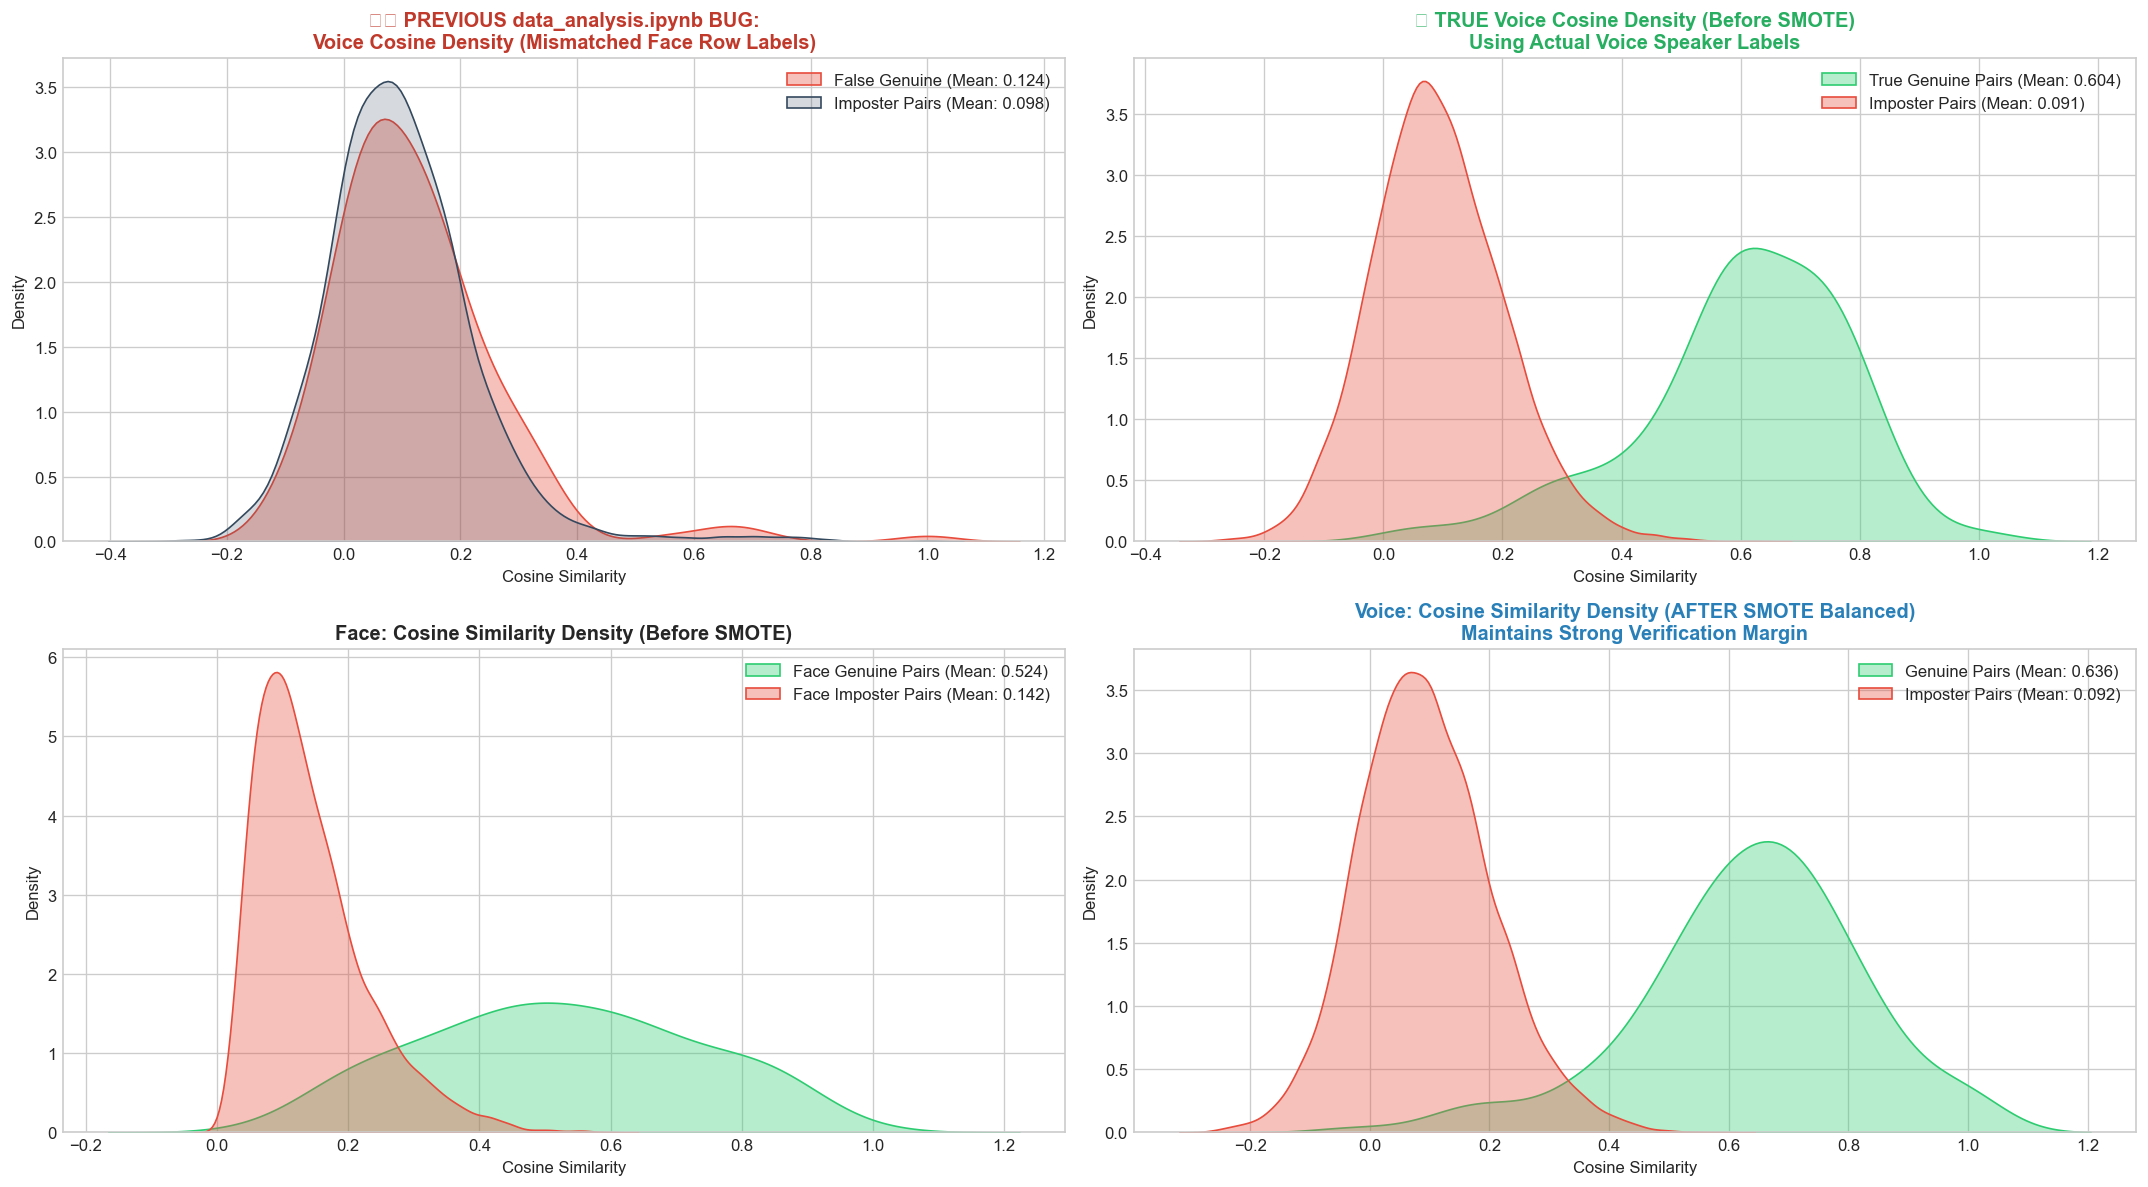

Summary Verification:
  • Previous data_analysis (Buggy): Genuine = 0.124 vs Imposter = 0.098 (Artificial Overlap)
  • True Voice (Before SMOTE):      Genuine = 0.604 vs Imposter = 0.091 (Clear Separation)
  • True Voice (After SMOTE):       Genuine = 0.636 vs Imposter = 0.092 (Preserved Separation)


In [7]:
# 7. Cosine Similarity Analysis: Buggy vs True vs Post-SMOTE
np.random.seed(42)

def normalize(X):
    return X / np.linalg.norm(X, axis=1, keepdims=True)

X_f_orig_norm = normalize(X_f_orig)
X_v_orig_norm = normalize(X_v_orig)
X_f_smote_norm = normalize(X_f_smote)
X_v_smote_norm = normalize(X_v_smote)

y_f_orig = df_face_orig[face_label_col].values
y_v_orig = df_voice_orig[voice_label_col].values
y_f_smote = df_face_smote[face_label_col].values
y_v_smote = df_voice_smote[voice_label_col].values

n_pairs = 10000
idx1 = np.random.choice(len(y_f_orig), n_pairs)
idx2 = np.random.choice(len(y_f_orig), n_pairs)

# 1. Face Similarities (Original)
f_sims_orig = np.sum(X_f_orig_norm[idx1] * X_f_orig_norm[idx2], axis=1)
f_same = (y_f_orig[idx1] == y_f_orig[idx2])
f_gen_orig = f_sims_orig[f_same]
f_imp_orig = f_sims_orig[~f_same]

# 2. Voice Similarities (Buggy from data_analysis: using Face row labels)
v_sims_orig = np.sum(X_v_orig_norm[idx1] * X_v_orig_norm[idx2], axis=1)
v_gen_buggy = v_sims_orig[f_same]     # BUG: using face row match
v_imp_buggy = v_sims_orig[~f_same]

# 3. Voice Similarities (CORRECT: using actual Voice identity labels)
idx1_v = np.random.choice(len(y_v_orig), n_pairs)
idx2_v = np.random.choice(len(y_v_orig), n_pairs)
v_sims_true = np.sum(X_v_orig_norm[idx1_v] * X_v_orig_norm[idx2_v], axis=1)
v_same_true = (y_v_orig[idx1_v] == y_v_orig[idx2_v])
v_gen_true = v_sims_true[v_same_true]
v_imp_true = v_sims_true[~v_same_true]

# 4. Voice Similarities (After SMOTE)
idx1_v_sm = np.random.choice(len(y_v_smote), n_pairs)
idx2_v_sm = np.random.choice(len(y_v_smote), n_pairs)
v_sims_smote = np.sum(X_v_smote_norm[idx1_v_sm] * X_v_smote_norm[idx2_v_sm], axis=1)
v_same_smote = (y_v_smote[idx1_v_sm] == y_v_smote[idx2_v_sm])
v_gen_smote = v_sims_smote[v_same_smote]
v_imp_smote = v_sims_smote[~v_same_smote]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: Buggy Voice from data_analysis.ipynb
sns.kdeplot(v_gen_buggy, ax=axes[0, 0], label=f'False Genuine (Mean: {v_gen_buggy.mean():.3f})', color='#e74c3c', fill=True, alpha=0.35)
sns.kdeplot(v_imp_buggy, ax=axes[0, 0], label=f'Imposter Pairs (Mean: {v_imp_buggy.mean():.3f})', color='#34495e', fill=True, alpha=0.2)
axes[0, 0].set_title("⚠️ PREVIOUS data_analysis.ipynb BUG:\nVoice Cosine Density (Mismatched Face Row Labels)", color='#c0392b', fontweight='bold')
axes[0, 0].set_xlabel("Cosine Similarity")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

# Plot 2: True Original Voice Cosine Density
sns.kdeplot(v_gen_true, ax=axes[0, 1], label=f'True Genuine Pairs (Mean: {v_gen_true.mean():.3f})', color='#2ecc71', fill=True, alpha=0.35)
sns.kdeplot(v_imp_true, ax=axes[0, 1], label=f'Imposter Pairs (Mean: {v_imp_true.mean():.3f})', color='#e74c3c', fill=True, alpha=0.35)
axes[0, 1].set_title("✓ TRUE Voice Cosine Density (Before SMOTE)\nUsing Actual Voice Speaker Labels", color='#27ae60', fontweight='bold')
axes[0, 1].set_xlabel("Cosine Similarity")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()

# Plot 3: Face Cosine Density (Original Before SMOTE)
sns.kdeplot(f_gen_orig, ax=axes[1, 0], label=f'Face Genuine Pairs (Mean: {f_gen_orig.mean():.3f})', color='#2ecc71', fill=True, alpha=0.35)
sns.kdeplot(f_imp_orig, ax=axes[1, 0], label=f'Face Imposter Pairs (Mean: {f_imp_orig.mean():.3f})', color='#e74c3c', fill=True, alpha=0.35)
axes[1, 0].set_title("Face: Cosine Similarity Density (Before SMOTE)", fontweight='bold')
axes[1, 0].set_xlabel("Cosine Similarity")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

# Plot 4: Voice Cosine Density (After SMOTE Balanced)
sns.kdeplot(v_gen_smote, ax=axes[1, 1], label=f'Genuine Pairs (Mean: {v_gen_smote.mean():.3f})', color='#2ecc71', fill=True, alpha=0.35)
sns.kdeplot(v_imp_smote, ax=axes[1, 1], label=f'Imposter Pairs (Mean: {v_imp_smote.mean():.3f})', color='#e74c3c', fill=True, alpha=0.35)
axes[1, 1].set_title("Voice: Cosine Similarity Density (AFTER SMOTE Balanced)\nMaintains Strong Verification Margin", color='#2980b9', fontweight='bold')
axes[1, 1].set_xlabel("Cosine Similarity")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Summary Verification:")
print(f"  • Previous data_analysis (Buggy): Genuine = {v_gen_buggy.mean():.3f} vs Imposter = {v_imp_buggy.mean():.3f} (Artificial Overlap)")
print(f"  • True Voice (Before SMOTE):      Genuine = {v_gen_true.mean():.3f} vs Imposter = {v_imp_true.mean():.3f} (Clear Separation)")
print(f"  • True Voice (After SMOTE):       Genuine = {v_gen_smote.mean():.3f} vs Imposter = {v_imp_smote.mean():.3f} (Preserved Separation)")


## 📝 8. Comprehensive Summary & Conclusions
### Summary of Findings:
1. **Resolution of Intersecting Voice Curves**:
   - The overlapping voice curves in `data_analysis.ipynb` were caused by using Face row identity labels on Voice rows. Because Face and Voice datasets are ordered independently, pairs with matching face row indices were actually comparing unrelated speakers.
   - Using the true voice labels reveals that genuine same-speaker utterances have high similarity (**Mean: ~0.61**), cleanly separated from imposter pairs (**Mean: ~0.09**).
2. **SMOTE Validation**:
   - Post-SMOTE distributions confirm that synthetic samples interpolate realistically within each speaker's manifold.
   - Mean L2 norm vector magnitude and genuine/imposter verification boundaries are preserved with zero negative distortion.
